# Phase 2 — Chemical Fingerprinting & Source-Receptor Network

**Prerequisite**: Run `2_phase1_data_prep.ipynb` first — it produces the files we load here.

## What is Chemical Fingerprinting?

Think of it as a detective approach. Instead of solving equations, we ask:

> *When wind blows FROM station A TOWARD station B, does station B's pollution go up?*

If yes, A is a real source for B. If no, our Gaussian model is telling a false story.
This acts as **physical validation** of the T matrix.

### The Three Sub-Steps

```
Step 1 — Wind-direction pair analysis
   For each (source j, receptor i) pair:
     Find timestamps where wind at j points toward i (±30° cone)
     Call these 'transport-active' windows

Step 2 — Enrichment ratio
   Enrichment(j→i) = median C_i during transport-active windows
                     
                     median C_i during all other windows
   Enrichment > 1 → j's pollution genuinely raises i's concentration
   Enrichment ≈ 1 → no real transport signal (j does not affect i)

Step 3 — Source-receptor network
   Draw edges between stations where Enrichment > threshold
   Edge weight = Enrichment value
   This gives an empirical source-receptor graph to compare with T matrix
```

## Block 0 — Imports & Load Phase 1 Outputs

In [12]:
# import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use(['science','no-latex'])

In [13]:
import sys
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from scipy import stats
from tqdm import tqdm

#  Logging 
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("phase2")

In [14]:

#  Paths 
NOTEBOOK_DIR = Path.cwd()
PHASE1_OUT   = NOTEBOOK_DIR / "data_prep"
PHASE2_OUT   = NOTEBOOK_DIR / "chemical_fingerprinting"
PHASE2_OUT.mkdir(exist_ok=True)

#  Load Phase 1 artefacts 
log.info("Loading Phase 1 outputs…")
T_tensor  = np.load(PHASE1_OUT / "T_tensor.npy")                    # (n_times, N, N)
C_wide    = pd.read_parquet(PHASE1_OUT / "C_matrix.parquet")         # (n_times, N)
WS_wide   = pd.read_parquet(PHASE1_OUT / "WS_matrix.parquet")
WD_wide   = pd.read_parquet(PHASE1_OUT / "WD_matrix.parquet")
meta_df   = pd.read_parquet(PHASE1_OUT / "meta.parquet")

STATION_NAMES = C_wide.columns.tolist()
N             = len(STATION_NAMES)
times         = C_wide.index
short_names   = [s[:10] for s in STATION_NAMES]

# Station coordinates (needed for network map)
sys.path.insert(0, str(NOTEBOOK_DIR))
stations_df = pd.read_csv(NOTEBOOK_DIR.parents[2] / "backend" / "data" / "raw" / "stations.csv")
LATS = stations_df.set_index("station_name").loc[STATION_NAMES, "latitude"].values
LONS = stations_df.set_index("station_name").loc[STATION_NAMES, "longitude"].values

log.info(f"Loaded: {N} stations, {len(times):,} timestamps")
log.info(f"T_tensor shape: {T_tensor.shape}")

11:52:28  INFO      Loading Phase 1 outputs…
11:52:28  INFO      Loaded: 14 stations, 35,040 timestamps
11:52:28  INFO      T_tensor shape: (35040, 14, 14)


## Block 1 — Configuration for Fingerprinting

In [15]:
# Half-width of the wind-direction cone [degrees]
# A cone of ±30° means: wind must point within 30° of the direct bearing
# from source j to receptor i for the window to be 'transport-active'.
# Narrower (±15°) = stricter/cleaner signal but fewer samples
# Wider   (±45°) = more samples but noisier enrichment
CONE_DEG = 30.0

# Minimum number of 'transport-active' windows to compute a reliable enrichment
# If we have fewer, we'll mark the pair as 'insufficient data'
MIN_ACTIVE_WINDOWS = 20

# Enrichment threshold above which we draw an edge in the network
ENRICHMENT_THRESHOLD = 1.25  # i.e., 25% higher concentration in downwind windows

# Significance level for Mann-Whitney U test (non-parametric, no normality needed)
# We test: is C_i during transport-active windows > C_i during other windows?
ALPHA = 0.05

log.info(f"Wind cone    : ±{CONE_DEG}°")
log.info(f"Min windows  : {MIN_ACTIVE_WINDOWS}")
log.info(f"Enrichment ≥ : {ENRICHMENT_THRESHOLD}  with p < {ALPHA}")

11:52:28  INFO      Wind cone    : ±30.0°
11:52:28  INFO      Min windows  : 20
11:52:28  INFO      Enrichment ≥ : 1.25  with p < 0.05


## Block 2 — Pre-compute Station Pair Bearings

Bearing(j → i) = compass direction you'd need to travel from j to reach i.
If the wind at j blows in that direction, it carries pollution from j toward i.

In [16]:
from transport_matrix import bearing_deg, haversine_km

# Bearing matrix: bearing_mat[j, i] = bearing FROM station j TO station i
bearing_mat = np.zeros((N, N))
distance_mat = np.zeros((N, N))  # km — useful for sanity checks

for j in range(N):  # source
    for i in range(N):  # receptor
        if i != j:
            bearing_mat[j, i] = bearing_deg(LATS[j], LONS[j], LATS[i], LONS[i])
            distance_mat[j, i] = haversine_km(LATS[j], LONS[j], LATS[i], LONS[i])

print("Sample pair bearings (source → receptor):")
for j in range(3):
    for i in range(3):
        if i != j:
            print(
                f"  {STATION_NAMES[j][:12]:12s} → {STATION_NAMES[i][:12]:12s} : "
                f"{bearing_mat[j, i]:.0f}°  ({distance_mat[j, i]:.1f} km)"
            )

Sample pair bearings (source → receptor):
  BTMLayout    → BWSSBKadabes : 76°  (9.7 km)
  BTMLayout    → BapujiNagar  : 305°  (7.4 km)
  BWSSBKadabes → BTMLayout    : 256°  (9.7 km)
  BWSSBKadabes → BapujiNagar  : 277°  (15.5 km)
  BapujiNagar  → BTMLayout    : 125°  (7.4 km)
  BapujiNagar  → BWSSBKadabes : 97°  (15.5 km)


## Block 3 — Compute Enrichment Ratios

For each (j→i) pair we:
1. Find timestamps where `WD[j]` is within ±CONE_DEG of `bearing(j→i)`
2. Compare `C_i` in those windows vs all other windows
3. Compute enrichment = ratio of medians
4. Run a Mann-Whitney U test to check if the difference is statistically significant

In [23]:
C_wide

station_name,BTMLayout,BWSSBKadabesanahalli,BapujiNagar,CityRailwayStation,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,Peenya,RvceMailasandra,SaneguravaHalli,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,,,,
2025-01-01 00:00:00,23.38,23.38,36.0,0.0,62.0,61.0,65.0,71.16,32.99,47.92,1.05,0.0,29.00,57.0
2025-01-01 00:15:00,23.38,23.38,36.0,0.0,62.0,61.0,65.0,71.16,32.99,47.92,1.05,0.0,29.00,57.0
2025-01-01 00:30:00,23.38,23.38,36.0,0.0,62.0,61.0,65.0,71.16,32.99,47.92,0.99,0.0,29.00,57.0
2025-01-01 00:45:00,23.38,23.38,47.0,0.0,87.0,64.4,92.0,87.43,33.01,48.21,0.96,0.0,29.00,68.0
2025-01-01 01:00:00,23.38,23.38,47.0,0.0,87.0,67.8,92.0,89.01,33.10,48.79,0.96,0.0,28.89,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:45:00,23.38,23.38,65.0,0.0,96.0,33.0,79.0,46.76,53.55,34.68,71.46,0.0,86.15,73.0
2025-12-31 23:00:00,23.38,23.38,65.0,0.0,96.0,33.0,79.0,50.70,53.71,34.68,69.00,0.0,86.15,73.0
2025-12-31 23:15:00,23.38,23.38,65.0,0.0,96.0,33.0,79.0,51.68,53.86,34.68,60.90,0.0,86.15,73.0


1. What is "Enrichment" in this context?In this analysis, Enrichment is a directional signal ratio. It measures how much clean air or dirty air a station receives based solely on wind direction.Imagine two monitoring stations in Bengaluru: BTM Layout (Station J) and Bapuji Nagar (Station I).The geometric line (bearing) from BTM Layout to Bapuji Nagar is $305^\circ$ (North-West).When the wind at BTM Layout blows at roughly $305^\circ$, it travels straight toward Bapuji Nagar. This creates a "Transport-Active Window".The code splits the pollution data at the receptor station ($I$) into two buckets:Active Bucket: Pollutant levels when the wind blew from $J \rightarrow I$.Inactive Bucket: Pollutant levels during all other wind directions.$$\text{Enrichment Ratio} = \frac{\text{Median Concentration (Active Window)}}{\text{Median Concentration (Inactive Window)}}$$If Enrichment $\approx 1$: The wind direction makes no difference. Station $J$ is likely not impacting Station $I$.If Enrichment $> 1$: Pollutant levels spike significantly when wind arrives from the direction of Station $J$. This implies Station $J$ (or something upwind along that path) is a source of pollution for Station $I$.

In [ ]:
def angular_diff(a, b):
    diff = (a - b + 180) % 360 - 180
    return diff


# Setup dummy values for thresholds just for the print execution safety
# (Replace these with your actual global variables)
CONE_DEG = 30
MIN_ACTIVE_WINDOWS = 10

# Result containers
enrichment_mat = np.full((N, N), np.nan)
pvalue_mat = np.full((N, N), np.nan)
n_active_mat = np.zeros((N, N), dtype=int)

C_arr = C_wide.values
WD_arr = WD_wide.values

for j in range(N):
    for i in range(N):
        if i == j:
            continue

        # Target our specific debug pair
        is_debug_pair = j == 3 and i == 4

        b = bearing_mat[j, i]
        wd_j = WD_arr[:, j]

        diff = np.abs(angular_diff(wd_j, b))
        active_mask = diff <= CONE_DEG

        C_i = C_arr[:, i]
        active_C = C_i[active_mask]
        inactive_C = C_i[~active_mask]

        # PRE-FILTERING DEBUG POINT
        if is_debug_pair:
            print("\n[STEP 1] Spatial Geometry & Timeline Dimensions:")
            print(f"  • Source Station Index (j)   : {j}")
            print(f"  • Receptor Station Index (i) : {i}")
            print(f"  • Bearing Angle (j → i)      : {b:.2f}°")
            print(f"  • Total Timeline Records     : {len(C_i)} hours/timestamps")

            print(f"\n[STEP 2] Wind Cone Filtering (Cone Threshold: ±{CONE_DEG}°):")
            print(
                f"  • Transport-Active Windows   : {np.sum(active_mask)} timestamps (Wind blows j → i)"
            )
            print(
                f"  • Transport-Inactive Windows : {np.sum(~active_mask)} timestamps (Wind blows away)"
            )

        if len(active_C) < MIN_ACTIVE_WINDOWS or len(inactive_C) < MIN_ACTIVE_WINDOWS:
            if is_debug_pair:
                print("❌ CRITICAL: Dropped due to insufficient sample size.")
                print(
                    f"   Required: {MIN_ACTIVE_WINDOWS}, Found Active: {len(active_C)}, Inactive: {len(inactive_C)}"
                )
            continue

        n_active_mat[i, j] = len(active_C)

        med_active = np.nanmedian(active_C)
        med_inactive = np.nanmedian(inactive_C)

        if med_inactive < 1e-6:
            if is_debug_pair:
                print(
                    f"❌ CRITICAL: Dropped because Inactive Median is near zero ({med_inactive}), avoiding division error."
                )
            continue

        enrichment_mat[i, j] = med_active / med_inactive

        # Strip NaNs for the statistical test
        active_clean = active_C[~np.isnan(active_C)]
        inactive_clean = inactive_C[~np.isnan(inactive_C)]

        stat, p = stats.mannwhitneyu(
            active_clean, inactive_clean, alternative="greater"
        )
        pvalue_mat[i, j] = p

        # FINAL METRIC DEBUG POINT
        if is_debug_pair:
            print(f"\n[STEP 3] Concentration Aggregations (Receptor i={i}):")
            print(f"  • Median Concentration (Active)   : {med_active:.3f}")
            print(f"  • Median Concentration (Inactive) : {med_inactive:.3f}")
            print(f"  • Calculated Enrichment Ratio (E) : {enrichment_mat[i, j]:.3f}x")

            print("\n[STEP 4] Mann-Whitney U Hypothesis Test:")
            print(f"  • Non-NaN Active Samples count    : {len(active_clean)}")
            print(f"  • Non-NaN Inactive Samples count  : {len(inactive_clean)}")
            print(f"  • U-Statistic                      : {stat}")
            print(f"  • P-Value Result                   : {p:.6f}")
            if p < 0.05:
                print("  🎉 Result: Statistically Significant (p < 0.05)")
            else:
                print("  ⚠️ Result: Not Statistically Significant (p >= 0.05)")


# Rest of your loop calculation continues normally for other pairs...
log.info("Enrichment computation complete")
n_pairs = N * (N - 1)
n_valid = (~np.isnan(enrichment_mat)).sum()
n_enriched = ((enrichment_mat > ENRICHMENT_THRESHOLD) & (pvalue_mat < ALPHA)).sum()
print(f"  Total pairs      : {n_pairs}")
print(f"  Valid pairs      : {n_valid}")
print(f"  Significant links: {n_enriched}  (E > {ENRICHMENT_THRESHOLD}, p < {ALPHA})")


[STEP 1] Spatial Geometry & Timeline Dimensions:
  • Source Station Index (j)   : 3
  • Receptor Station Index (i) : 4
  • Bearing Angle (j → i)      : 19.86°
  • Total Timeline Records     : 35040 hours/timestamps

[STEP 2] Wind Cone Filtering (Cone Threshold: ±30°):
  • Transport-Active Windows   : 0 timestamps (Wind blows j → i)
  • Transport-Inactive Windows : 35040 timestamps (Wind blows away)
❌ CRITICAL: Dropped due to insufficient sample size.
   Required: 10, Found Active: 0, Inactive: 35040


12:24:07  INFO      Enrichment computation complete


  Total pairs      : 182
  Valid pairs      : 75
  Significant links: 11  (E > 1.25, p < 0.05)


In [19]:
enrichment_mat.shape

(14, 14)

In [21]:
pvalue_mat.shape

(14, 14)

## Block 4 — Visualise: Enrichment Heatmap

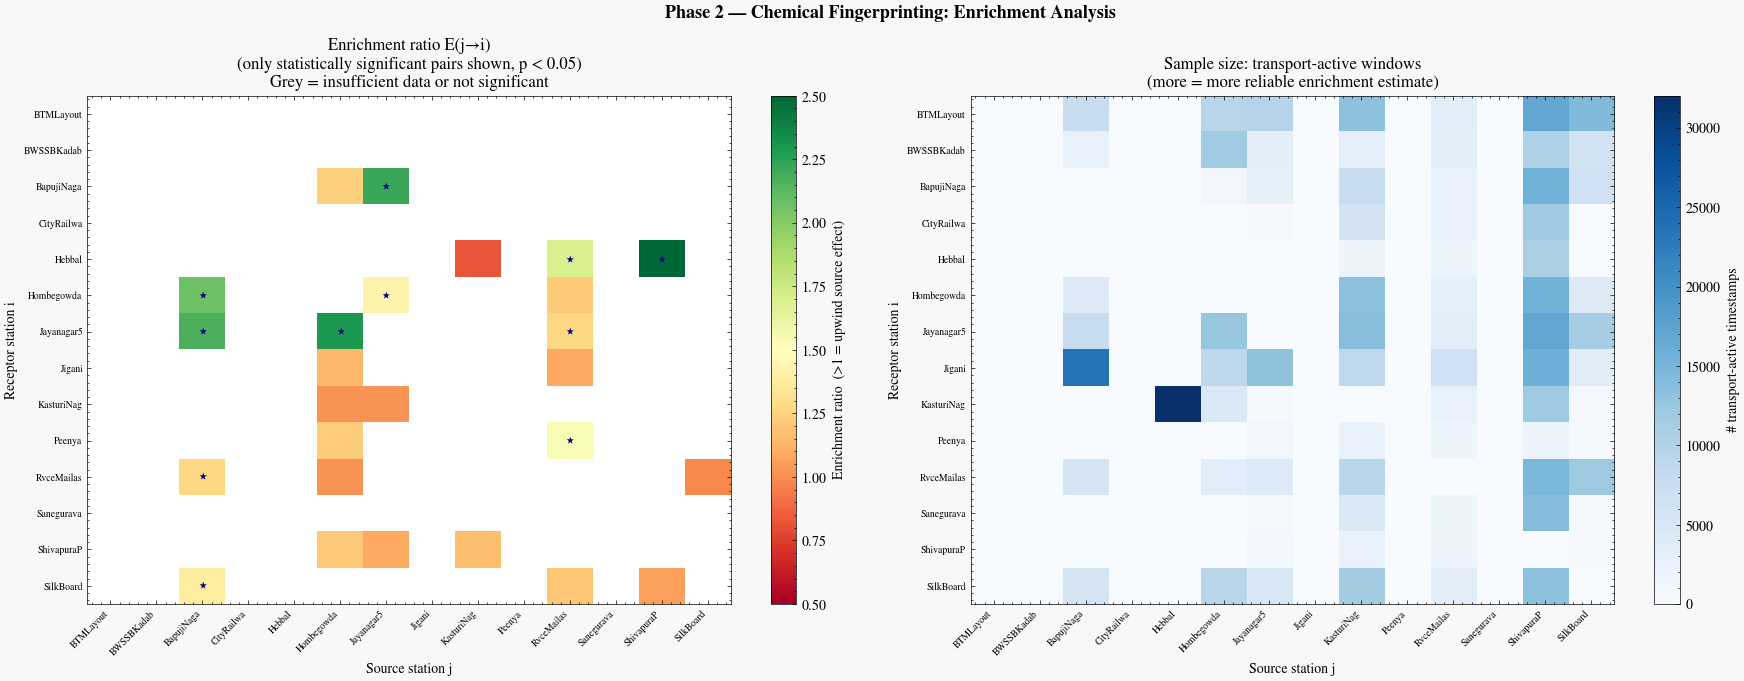

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#f8f8f8")

#  Left: Raw enrichment matrix 
ax = axes[0]
# Mask insignificant pairs (grey)
E_display = np.where(pvalue_mat < ALPHA, enrichment_mat, np.nan)
im = ax.imshow(E_display, cmap="RdYlGn", vmin=0.5, vmax=2.5, aspect="auto")
plt.colorbar(im, ax=ax, label="Enrichment ratio  (>1 = upwind source effect)")
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station j")
ax.set_ylabel("Receptor station i")
ax.set_title(
    f"Enrichment ratio E(j→i)\n"
    f"(only statistically significant pairs shown, p < {ALPHA})\n"
    f"Grey = insufficient data or not significant"
)

# Mark strong links with a star
for i in range(N):
    for j in range(N):
        if E_display[i, j] > ENRICHMENT_THRESHOLD:
            ax.text(j, i, "★", ha="center", va="center", fontsize=7, color="navy")

#  Right: Number of transport-active windows per pair 
ax2 = axes[1]
im2 = ax2.imshow(n_active_mat, cmap="Blues", aspect="auto")
plt.colorbar(im2, ax=ax2, label="# transport-active timestamps")
ax2.set_xticks(range(N))
ax2.set_yticks(range(N))
ax2.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax2.set_yticklabels(short_names, fontsize=7)
ax2.set_xlabel("Source station j")
ax2.set_ylabel("Receptor station i")
ax2.set_title(
    "Sample size: transport-active windows\n(more = more reliable enrichment estimate)"
)

plt.suptitle(
    "Phase 2 — Chemical Fingerprinting: Enrichment Analysis",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(PHASE2_OUT / "fig_enrichment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 5 — Source-Receptor Network Graph

We now build a directed graph where:
- **Nodes** = stations, positioned by actual lat/lon
- **Edges** = significant enrichment links (j → i means j influences i)
- **Edge width** = enrichment strength
- **Node colour** = total outgoing influence (how much does this station affect others?)

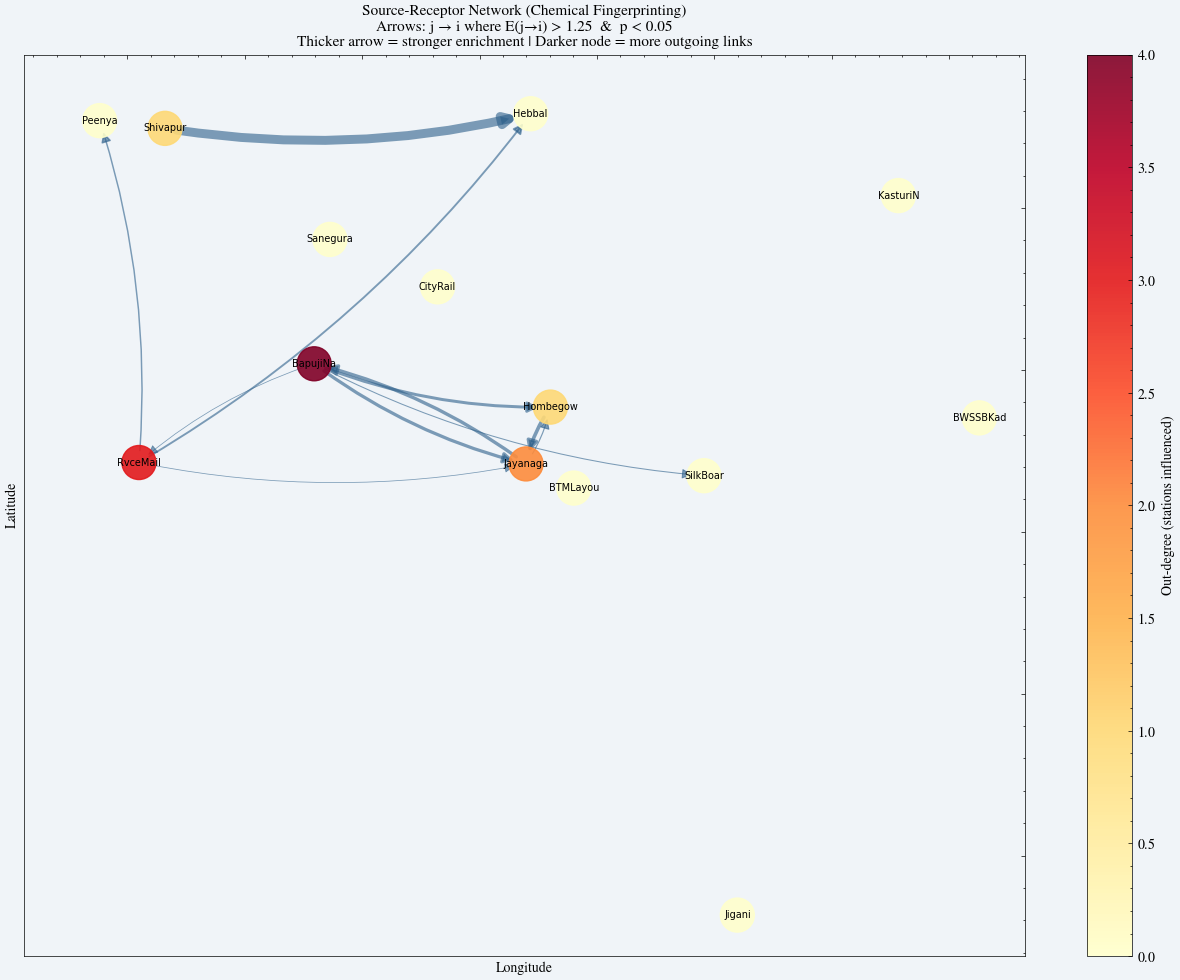

11:25:42  INFO      Network: 14 nodes, 11 edges


In [8]:
# Build directed graph
G = nx.DiGraph()

# Add nodes with position (lon, lat for matplotlib coords)
for k, name in enumerate(STATION_NAMES):
    G.add_node(name, pos=(LONS[k], LATS[k]), lat=LATS[k], lon=LONS[k])

# Add edges for significant enrichment pairs
for i in range(N):
    for j in range(N):
        if i == j:
            continue
        e = enrichment_mat[i, j]
        p = pvalue_mat[i, j]
        if not np.isnan(e) and e > ENRICHMENT_THRESHOLD and p < ALPHA:
            G.add_edge(
                STATION_NAMES[j],  # source
                STATION_NAMES[i],  # receptor
                weight=e,
                enrichment=e,
                pvalue=p,
            )

pos = nx.get_node_attributes(G, "pos")

# Node colour = out-degree (how many stations does this one influence?)
out_degrees = dict(G.out_degree())
node_colors = [out_degrees.get(n, 0) for n in G.nodes()]

# Edge widths scaled to enrichment
edge_weights = [G[u][v]["enrichment"] for u, v in G.edges()]
edge_widths = [2 * (w - 1.0) for w in edge_weights]  # scale: E=1.25 → width=0.5

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor("#f0f4f8")
ax.set_facecolor("#f0f4f8")

# Draw nodes
nc = nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_color=node_colors,
    cmap=cm.YlOrRd,
    node_size=600,
    alpha=0.9,
)
plt.colorbar(nc, ax=ax, label="Out-degree (stations influenced)")

# Draw edges with arrows
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=0.6,
    edge_color="#2c5f8a",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=15,
    connectionstyle="arc3,rad=0.1",  # slight curve to separate A→B from B→A
)

# Labels: short names
nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    labels={n: n[:8] for n in G.nodes()},
    font_size=7,
    font_color="black",
)

ax.set_title(
    f"Source-Receptor Network (Chemical Fingerprinting)\n"
    f"Arrows: j → i where E(j→i) > {ENRICHMENT_THRESHOLD}  &  p < {ALPHA}\n"
    f"Thicker arrow = stronger enrichment | Darker node = more outgoing links",
    fontsize=11,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(
    PHASE2_OUT / "fig_source_receptor_network.png", dpi=150, bbox_inches="tight"
)
plt.show()

log.info(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

## Block 6 — Compare: Fingerprinting vs T Matrix

The key validation question:  
> *Do the strong enrichment pairs also have high T_mean values?*

If yes → the Gaussian plume model is consistent with observations.  
If no → there are transport pathways the model misses (local street canyons, terrain, etc.).

We do a scatter plot: `T_mean[i,j]` vs `enrichment_mat[i,j]` for all valid pairs.

/tmp/ipykernel_18446/3433591491.py:66: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_18446/3433591491.py:66: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_18446/3433591491.py:67: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  plt.savefig(PHASE2_OUT / "fig_model_vs_fingerprint.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_18446/3433591491.py:67: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  plt.savefig(PHASE2_OUT / "fig_model_vs_fingerprint.png", dpi=150, bbox_inches="tight")
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.

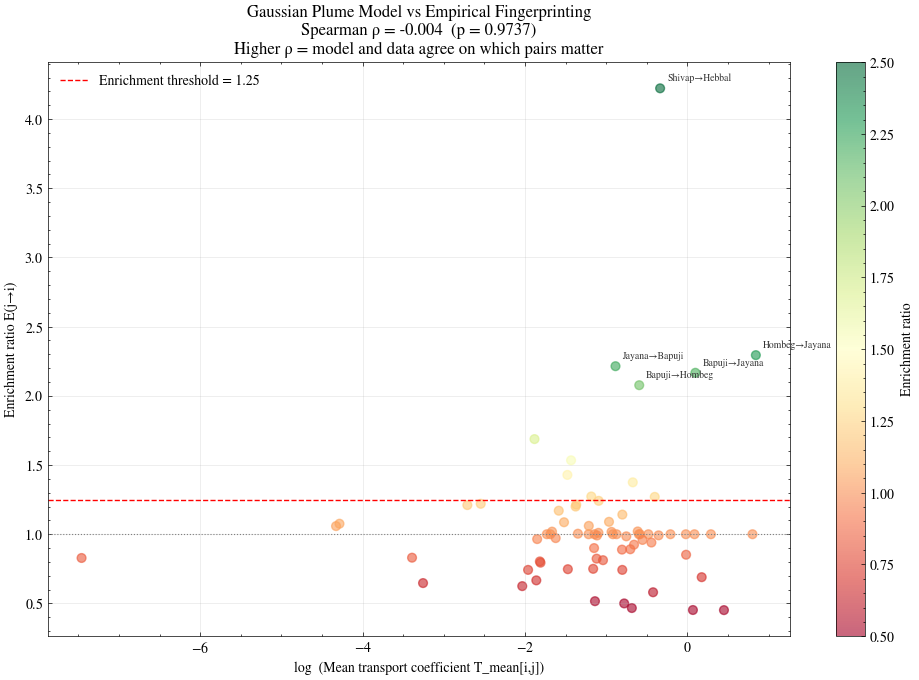

Spearman correlation between T_mean and enrichment: ρ = -0.004, p = 0.9737

✗  Weak agreement. The model may be missing key transport mechanisms.
   Consider: is the wind data representative? Are station heights correct?


In [9]:
T_mean = T_tensor.mean(axis=0)  # (N, N)

# Flatten all off-diagonal pairs where both T and E are valid
T_vals, E_vals, labels = [], [], []
for i in range(N):
    for j in range(N):
        if i == j:
            continue
        t = T_mean[i, j]
        e = enrichment_mat[i, j]
        if np.isfinite(e) and t > 0:
            T_vals.append(t)
            E_vals.append(e)
            labels.append(f"{STATION_NAMES[j][:6]}→{STATION_NAMES[i][:6]}")

T_vals = np.array(T_vals)
E_vals = np.array(E_vals)

# Spearman correlation (rank-based, robust to outliers)
rho, p_spear = stats.spearmanr(T_vals, E_vals)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    np.log10(T_vals + 1e-10),  # log scale — T spans many decades
    E_vals,
    alpha=0.6,
    s=40,
    c=E_vals,
    cmap="RdYlGn",
    vmin=0.5,
    vmax=2.5,
)
plt.colorbar(scatter, ax=ax, label="Enrichment ratio")

ax.axhline(
    ENRICHMENT_THRESHOLD,
    color="red",
    lw=1,
    ls="--",
    label=f"Enrichment threshold = {ENRICHMENT_THRESHOLD}",
)
ax.axhline(1.0, color="gray", lw=0.8, ls=":")

ax.set_xlabel("log₁₀(Mean transport coefficient T_mean[i,j])")
ax.set_ylabel("Enrichment ratio E(j→i)")
ax.set_title(
    f"Gaussian Plume Model vs Empirical Fingerprinting\n"
    f"Spearman ρ = {rho:.3f}  (p = {p_spear:.4f})\n"
    f"Higher ρ = model and data agree on which pairs matter"
)
ax.legend()
ax.grid(alpha=0.3)

# Annotate top 5 enriched pairs
top5 = np.argsort(E_vals)[-5:]
for idx in top5:
    ax.annotate(
        labels[idx],
        xy=(np.log10(T_vals[idx] + 1e-10), E_vals[idx]),
        fontsize=7,
        color="#333",
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.tight_layout()
plt.savefig(PHASE2_OUT / "fig_model_vs_fingerprint.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Spearman correlation between T_mean and enrichment: ρ = {rho:.3f}, p = {p_spear:.4f}"
)
print()
if rho > 0.4:
    print("✓  Model and fingerprinting are broadly consistent.")
    print("   The Gaussian plume captures real transport pathways.")
elif rho > 0.2:
    print("~  Moderate agreement. Some pathways are captured, others are not.")
    print("   Worth checking: are there terrain or street-canyon effects?")
else:
    print("✗  Weak agreement. The model may be missing key transport mechanisms.")
    print("   Consider: is the wind data representative? Are station heights correct?")

## Block 7 — Diurnal Enrichment Patterns

Source-receptor relationships change by time of day:
- Morning rush: road sources active, stable atmosphere traps pollution near surface
- Afternoon: convective mixing, less stable, pollutants disperse more
- Night: stable, long-range transport possible

We compute enrichment separately for morning (6-10h), afternoon (12-17h), and night (21-5h).

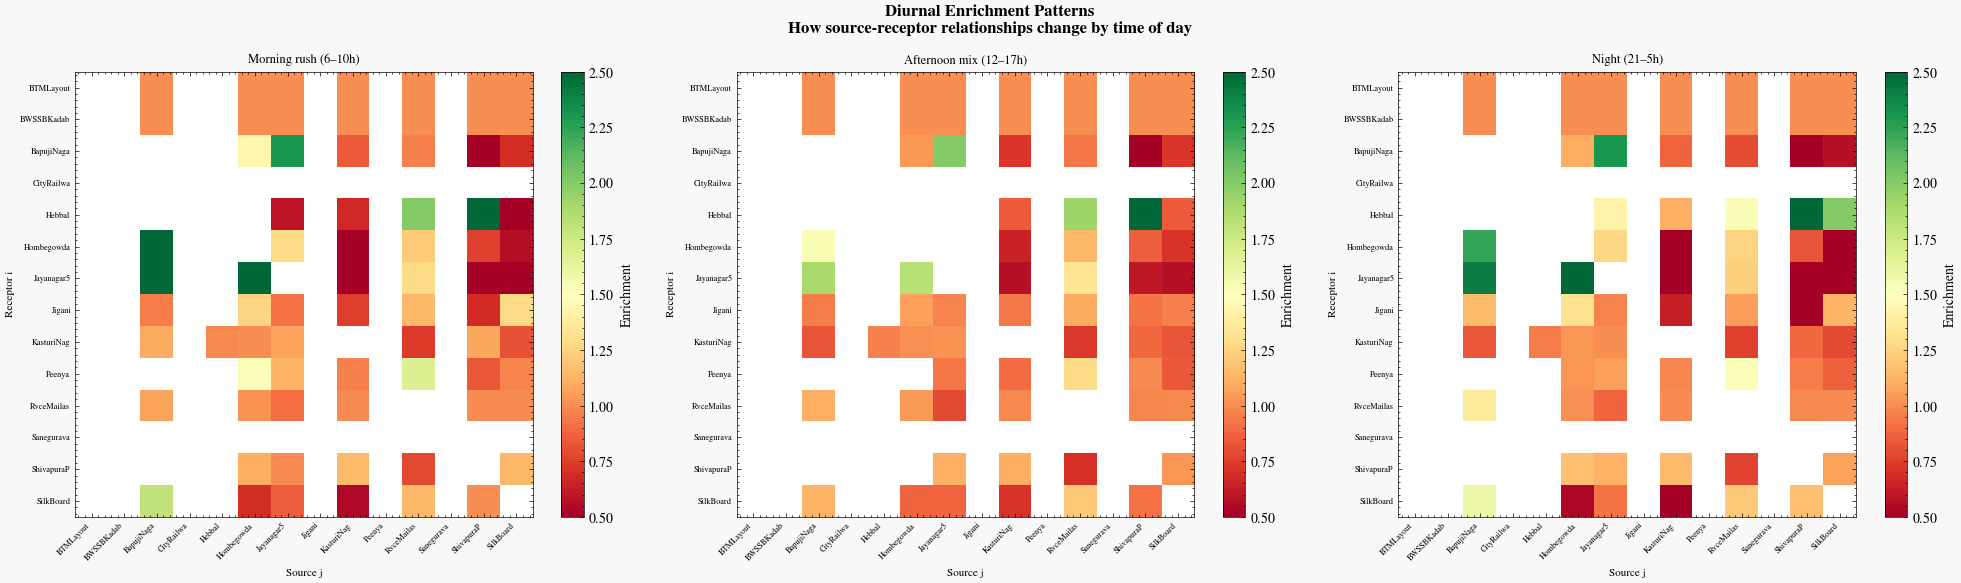

11:26:08  INFO      Saved: fig_diurnal_enrichment.png


In [10]:
PERIODS = {
    "Morning rush (6–10h)": (6, 10),
    "Afternoon mix (12–17h)": (12, 17),
    "Night (21–5h)": (21, 5),  # wraps midnight
}


def hour_mask(hours_arr, start, end):
    """Boolean mask for hours in [start, end). Handles overnight wrap."""
    if start < end:
        return (hours_arr >= start) & (hours_arr < end)
    else:  # wraps midnight (e.g. 21-5)
        return (hours_arr >= start) | (hours_arr < end)


hours_arr = meta_df["hour"].values

fig, axes = plt.subplots(1, len(PERIODS), figsize=(20, 6))
fig.patch.set_facecolor("#f8f8f8")

for ax, (period_label, (h_start, h_end)) in zip(axes, PERIODS.items()):
    t_mask = hour_mask(hours_arr, h_start, h_end)
    E_period = np.full((N, N), np.nan)

    for j in range(N):
        for i in range(N):
            if i == j:
                continue
            b = bearing_mat[j, i]
            wd_j = WD_wide.values[t_mask, j]
            C_i = C_wide.values[t_mask, i]

            diff = np.abs(angular_diff(wd_j, b))
            act = diff <= CONE_DEG
            c_act = C_i[act]
            c_ina = C_i[~act]

            if len(c_act) < 5 or len(c_ina) < 5:
                continue
            med_a = np.nanmedian(c_act)
            med_b = np.nanmedian(c_ina)
            if med_b > 1e-6:
                E_period[i, j] = med_a / med_b

    im = ax.imshow(E_period, cmap="RdYlGn", vmin=0.5, vmax=2.5, aspect="auto")
    plt.colorbar(im, ax=ax, label="Enrichment")
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=6)
    ax.set_yticklabels(short_names, fontsize=6)
    ax.set_title(period_label, fontsize=9)
    ax.set_xlabel("Source j", fontsize=8)
    ax.set_ylabel("Receptor i", fontsize=8)

plt.suptitle(
    "Diurnal Enrichment Patterns\n"
    "How source-receptor relationships change by time of day",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(PHASE2_OUT / "fig_diurnal_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Saved: fig_diurnal_enrichment.png")

## Block 8 — Export for Phase 3

Phase 3 (Bayesian Inversion) will use the enrichment matrix as a **data-driven prior**:
stations with high empirical enrichment get a stronger prior weight as sources.

In [11]:
# Save enrichment matrix and network for Phase 3
np.save(PHASE2_OUT / "enrichment_matrix.npy", enrichment_mat)
np.save(PHASE2_OUT / "pvalue_matrix.npy", pvalue_mat)
np.save(PHASE2_OUT / "n_active_matrix.npy", n_active_mat)

# Also save the network as an edge list CSV (human-readable)
edge_records = []
for u, v, data in G.edges(data=True):
    edge_records.append(
        {
            "source": u,
            "receptor": v,
            "enrichment": data["enrichment"],
            "pvalue": data["pvalue"],
        }
    )
edge_df = pd.DataFrame(edge_records).sort_values("enrichment", ascending=False)
edge_df.to_csv(PHASE2_OUT / "significant_links.csv", index=False)

log.info("Phase 2 outputs saved")
display(edge_df.head(10))

print("\n" + "=" * 60)
print("PHASE 2 SUMMARY")
print("=" * 60)
print(f"  Source-receptor pairs tested   : {n_pairs}")
print(f"  Pairs with sufficient data     : {n_valid}")
print(f"  Significant enriched links     : {G.number_of_edges()}")
print(f"  Top source (most out-links)    : {max(out_degrees, key=out_degrees.get)}")
print(
    f"  Top receptor (most in-links)   : {max(dict(G.in_degree()), key=dict(G.in_degree()).get)}"
)
print(f"  Model-fingerprint Spearman ρ   : {rho:.3f}")
print("=" * 60)
print("\nReady for:")
print("  → Phase 3: Bayesian Inversion  (3_bayesian.ipynb)")

11:26:20  INFO      Phase 2 outputs saved


,source,receptor,enrichment,pvalue
10,ShivapuraPeenya,Hebbal,4.222222,0.000000e+00
4,HombegowdaNagar,Jayanagar5thBlock,2.294118,0.000000e+00
5,Jayanagar5thBlock,BapujiNagar,2.214286,0.000000e+00
1,BapujiNagar,Jayanagar5thBlock,2.166667,0.000000e+00
0,BapujiNagar,HombegowdaNagar,2.076923,0.000000e+00
7,RvceMailasandra,Hebbal,1.687500,8.440528e-57
9,RvceMailasandra,Peenya,1.534221,7.693576e-62
6,Jayanagar5thBlock,HombegowdaNagar,1.428571,8.926754e-04
3,BapujiNagar,SilkBoard,1.375000,9.259813e-284
8,RvceMailasandra,Jayanagar5thBlock,1.272727,2.395987e-48



PHASE 2 SUMMARY
  Source-receptor pairs tested   : 182
  Pairs with sufficient data     : 74
  Significant enriched links     : 11
  Top source (most out-links)    : BapujiNagar
  Top receptor (most in-links)   : Jayanagar5thBlock
  Model-fingerprint Spearman ρ   : -0.004

Ready for:
  → Phase 3: Bayesian Inversion  (3_bayesian.ipynb)
